--- SIMULATION RESULTS ---
 Bunker Price ($/MT)  L1 Opt Speed (kn)  L2 Opt Speed (kn)  Fleet Size (N)  Weekly Cost ($M)  Transit Time (Days)
                1000              19.16              19.16               4             8.407                 12.0
                1500              16.74              19.11               4             9.406                 12.0
                2000              15.21              19.11               4            10.404                 12.0
                2500              14.12              14.80               5            11.173                 15.5
                3000              13.29              14.80               5            11.772                 15.5

Break-Even Tipping Point: $2219.61 / MT


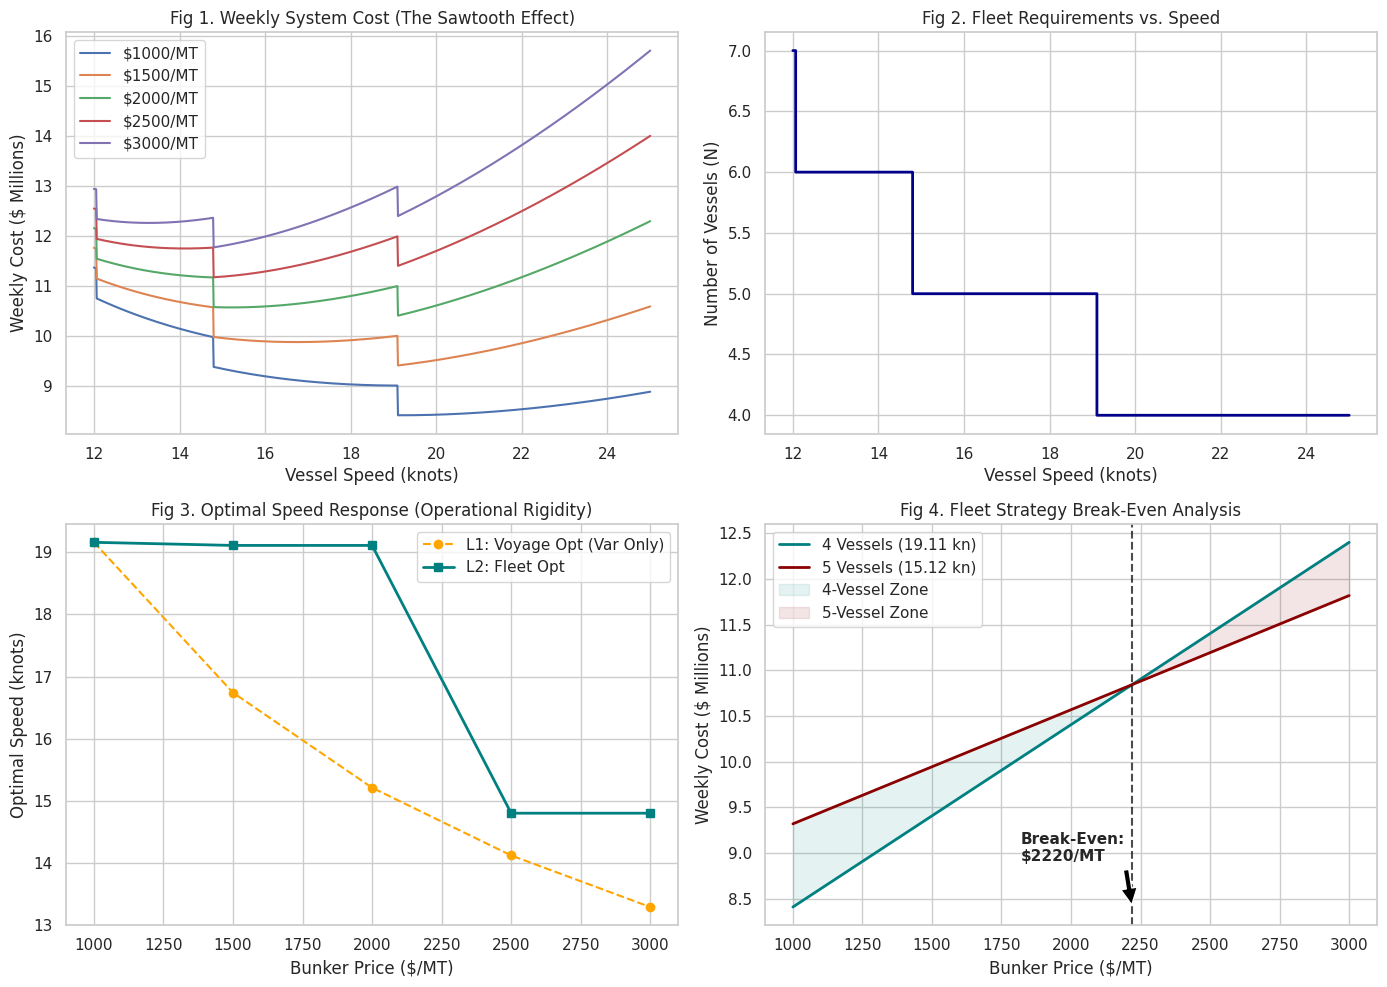

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (14, 10), 'font.size': 11})

# ==========================================
# 1. PARAMETERS
# ==========================================
PARAMS = {
    'D': 5500,            # Route distance (nmi)
    'v0': 24,             # Design speed (knots)
    'alpha': 165,         # Fuel consumption at design speed (MT/day)
    'h': 168000,          # Daily inventory holding cost ($/day)
    'cop': 20000,         # Daily vessel operating cost ($/day)
    'ccap_week': 455000,  # Weekly charter cost ($/vessel)
    'port_time': 4        # Total port time per round trip (days)
}

# Updated Price Brackets
PRICES = [1000, 1500, 2000, 2500, 3000]
SPEED_RANGE = np.linspace(12, 25, 1000)

# ==========================================
# 2. CORE FUNCTIONS
# ==========================================
def calculate_costs(v, p, params):
    """Calculates Layer 1 (Voyage) and Layer 2 (System) costs based on the corrected accounting model."""
    # Layer 1: Voyage Variable Costs (1 One-Way Trip)
    transit_time = params['D'] / (24 * v)
    c_fuel = p * params['alpha'] * (v / params['v0'])**3 * transit_time
    c_inv = params['h'] * transit_time
    
    # OPEX is removed from here; it is a fixed fleet cost.
    tc_voyage_var = c_fuel + c_inv 
    
    # Layer 2: Fleet Frequency Metrics
    t_round = (2 * params['D'] / (24 * v)) + params['port_time']
    n_vessels = np.ceil(t_round / 7)
    
    # Weekly System Cost
    weekly_variable_costs = 2 * tc_voyage_var # 2 one-way trips per week guaranteed
    weekly_fixed_costs = n_vessels * (params['ccap_week'] + (7 * params['cop'])) # Applied 24/7 across the fleet
    
    tc_ext = weekly_variable_costs + weekly_fixed_costs
    
    return tc_voyage_var, tc_ext, n_vessels

def run_scenario_simulation():
    """Runs the simulation across all defined prices and speeds."""
    results = []
    detailed_curves = {}

    for p in PRICES:
        l1_costs, l2_costs, n_counts = [], [], []
        
        for v in SPEED_RANGE:
            tc_v, tc_e, n = calculate_costs(v, p, PARAMS)
            l1_costs.append(tc_v)
            l2_costs.append(tc_e)
            n_counts.append(n)
        
        idx_l1, idx_l2 = np.argmin(l1_costs), np.argmin(l2_costs)
        v_star_l1, v_star_l2 = SPEED_RANGE[idx_l1], SPEED_RANGE[idx_l2]
        
        results.append({
            "Bunker Price ($/MT)": p,
            "L1 Opt Speed (kn)": round(v_star_l1, 2),
            "L2 Opt Speed (kn)": round(v_star_l2, 2),
            "Fleet Size (N)": int(n_counts[idx_l2]),
            "Weekly Cost ($M)": round(l2_costs[idx_l2] / 1e6, 3),
            "Transit Time (Days)": round(PARAMS['D'] / (24 * v_star_l2), 1)
        })
        detailed_curves[p] = {'speed': SPEED_RANGE, 'l2_cost': l2_costs, 'n': n_counts}
        
    return pd.DataFrame(results), detailed_curves

def find_break_even():
    """Finds the price where the 5-vessel strategy becomes cheaper than 4 vessels."""
    p_range = np.linspace(1000, 3000, 2000) 
    costs_4, costs_5 = [], []
    break_p = None
    
    for p in p_range:
        tc_4 = calculate_costs(19.11, p, PARAMS)[1] # Min speed for 4 vessels
        tc_5 = calculate_costs(15.12, p, PARAMS)[1] # Optimal lower speed for 5
        costs_4.append(tc_4 / 1e6)
        costs_5.append(tc_5 / 1e6)
        
        if tc_5 < tc_4 and break_p is None:
            break_p = p
            
    return break_p, p_range, np.array(costs_4), np.array(costs_5)

# ==========================================
# 3. VISUALIZATION MODULE
# ==========================================
def plot_results(detailed_curves, df_results, break_even_data):
    fig, axs = plt.subplots(2, 2)
    
    # Plot 1: Sawtooth Curves
    for p in PRICES:
        axs[0, 0].plot(detailed_curves[p]['speed'], [c/1e6 for c in detailed_curves[p]['l2_cost']], label=f'${p}/MT')
    axs[0, 0].set_title("Fig 1. Weekly System Cost (The Sawtooth Effect)")
    axs[0, 0].set_xlabel("Vessel Speed (knots)")
    axs[0, 0].set_ylabel("Weekly Cost ($ Millions)")
    axs[0, 0].legend()

    # Plot 2: Fleet Step Function (Updated to use a valid price key, 2000)
    base_price_for_plot = 2000
    axs[0, 1].step(detailed_curves[base_price_for_plot]['speed'], detailed_curves[base_price_for_plot]['n'], where='post', color='darkblue', lw=2)
    axs[0, 1].set_title("Fig 2. Fleet Requirements vs. Speed")
    axs[0, 1].set_xlabel("Vessel Speed (knots)")
    axs[0, 1].set_ylabel("Number of Vessels (N)")

    # Plot 3: Sticky Speed
    axs[1, 0].plot(df_results["Bunker Price ($/MT)"], df_results["L1 Opt Speed (kn)"], 'o--', label='L1: Voyage Opt (Var Only)', color='orange')
    axs[1, 0].plot(df_results["Bunker Price ($/MT)"], df_results["L2 Opt Speed (kn)"], 's-', label='L2: Fleet Opt', color='teal', lw=2)
    axs[1, 0].set_title("Fig 3. Optimal Speed Response (Operational Rigidity)")
    axs[1, 0].set_xlabel("Bunker Price ($/MT)")
    axs[1, 0].set_ylabel("Optimal Speed (knots)")
    axs[1, 0].legend()

    # Plot 4: Break-Even Analysis
    break_p, p_range, costs_4, costs_5 = break_even_data
    axs[1, 1].plot(p_range, costs_4, label='4 Vessels (19.11 kn)', color='teal', lw=2)
    axs[1, 1].plot(p_range, costs_5, label='5 Vessels (15.12 kn)', color='darkred', lw=2)
    
    if break_p:
        axs[1, 1].axvline(x=break_p, color='black', linestyle='--', lw=1.5, alpha=0.7)
        axs[1, 1].fill_between(p_range, costs_4, costs_5, where=(costs_4 < costs_5), color='teal', alpha=0.1, label='4-Vessel Zone')
        axs[1, 1].fill_between(p_range, costs_4, costs_5, where=(costs_5 <= costs_4), color='darkred', alpha=0.1, label='5-Vessel Zone')
        # Adjusted label position slightly so it looks clean with the new higher break-even price
        axs[1, 1].annotate(f'Break-Even:\n${break_p:.0f}/MT', xy=(break_p, min(costs_4)), xytext=(break_p - 400, min(costs_4) + 0.5),
                           arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')

    axs[1, 1].set_title("Fig 4. Fleet Strategy Break-Even Analysis")
    axs[1, 1].set_xlabel("Bunker Price ($/MT)")
    axs[1, 1].set_ylabel("Weekly Cost ($ Millions)")
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    df_results, detailed_curves = run_scenario_simulation()
    break_even_data = find_break_even()
    
    print("--- SIMULATION RESULTS ---")
    print(df_results.to_string(index=False))
    
    if break_even_data[0]:
        print(f"\nBreak-Even Tipping Point: ${break_even_data[0]:.2f} / MT")
    else:
        print("\nBreak-Even Tipping Point exceeds tested range.")
        
    plot_results(detailed_curves, df_results, break_even_data)